In [1]:
import duckdb
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from networks.feed_forward_base import NeuralModel
from networks.feed_forward_base import build_dataloaders

con = duckdb.connect('../capillary.db')

df = con.execute(""" SELECT row_id, value, label, set FROM protein_data WHERE value IS NOT NULL
                 AND observation_nr = 1
                 AND analysis IS NOT NULL
                 AND protein_value IS NOT NULL""").df()

con.close()


print(f"Antal fall med M-komponent:{(df['label'] == 1).sum()}")
print(f"Antal fall utan M-komponent:{(df['label'] == 0).sum()}")


train_rows = df[df['set'] == 'train']
val_rows = df[df['set'] == 'val']
test_rows = df[df['set'] == 'test']

drop_indices = train_rows[train_rows['label'] == 0].sample(frac=0.7).index


train_rows = train_rows.drop(drop_indices)
train_rows = train_rows[train_rows['label'].isin([0,1])]
val_rows = val_rows[val_rows['label'].isin([0,1])]

print(f"Antal utan m-komponent i träningsdatan: {len(train_rows[train_rows['label'] == 0])}")
print(f"Antal med m-komponent i träningsdatan: {len(train_rows[train_rows['label'] == 1])}")

network = NeuralModel()
network.reset_weights()
cnn_train_dl, cnn_val_dl, _ = build_dataloaders(train_rows, val_rows, val_rows)
network.retrain(cnn_train_dl,cnn_val_dl,patience=15)

Antal fall med M-komponent:2942
Antal fall utan M-komponent:69882
Antal utan m-komponent i träningsdatan: 17903
Antal med m-komponent i träningsdatan: 2553
Total parameters: 249,922
  -> ny bästa modell sparad till ../models/feed_forward_basic.pth
Epoch   0 | train: 1.1257 | val: 0.4143 | acc: 96.35% | AUC: 0.766  | LR: 0.001
  -> ny bästa modell sparad till ../models/feed_forward_basic.pth
Epoch   1 | train: 0.5877 | val: 0.4195 | acc: 89.30% | AUC: 0.838  | LR: 0.001
  -> ny bästa modell sparad till ../models/feed_forward_basic.pth
Epoch   2 | train: 0.5269 | val: 0.5550 | acc: 70.82% | AUC: 0.859  | LR: 0.001
  -> ny bästa modell sparad till ../models/feed_forward_basic.pth
Epoch   3 | train: 0.4687 | val: 0.5333 | acc: 73.59% | AUC: 0.885  | LR: 0.001
  -> ny bästa modell sparad till ../models/feed_forward_basic.pth
Epoch   4 | train: 0.4604 | val: 0.3227 | acc: 94.19% | AUC: 0.905  | LR: 0.001
Epoch   5 | train: 0.4103 | val: 0.3302 | acc: 95.23% | AUC: 0.840  | LR: 0.001
Epoch   

In [2]:
con = duckdb.connect('../capillary.db')
df = con.execute(""" 
                 SELECT row_id, value,label, set
                 FROM protein_data
                 WHERE value IS NOT NULL
                 AND observation_nr = 1
                 AND analysis IS NOT NULL
                 AND protein_value IS NOT NULL
                 """).df()
con.close()


k_fold_rows = df[df['set'].isin(['train','val']) ].copy()
k_fold_rows = k_fold_rows[k_fold_rows['label'].isin([0,1])]
drop_indices = k_fold_rows[k_fold_rows['label'] == 0].sample(frac=0.7).index
k_fold_rows = k_fold_rows.drop(drop_indices)
print(f"Totalt antal utan m-komponent i K-fold poolen: {len(k_fold_rows[k_fold_rows['label'] == 0])}")
print(f"Totalt antal med m-komponent i K-fold poolen: {len(k_fold_rows[k_fold_rows['label'] == 1])}")

test_rows  = df[df['set'] == 'test']


network = NeuralModel()
network.retrain_with_k_fold(k_fold_rows,k=10)

Totalt antal utan m-komponent i K-fold poolen: 18848
Totalt antal med m-komponent i K-fold poolen: 2692
Total parameters: 249,922
--- Startar 10-Fold Cross Validation ---

 FOLD 1/10
  -> ny bästa modell sparad till ../models/feed_forward_basic_fold1.pth
Epoch   0 | train: 1.0926 | val: 0.6285 | acc: 52.60% | AUC: 0.749  | LR: 0.001
  -> ny bästa modell sparad till ../models/feed_forward_basic_fold1.pth
Epoch   1 | train: 0.5689 | val: 0.5581 | acc: 90.30% | AUC: 0.804  | LR: 0.001
Epoch   2 | train: 0.5074 | val: 0.5475 | acc: 91.69% | AUC: 0.788  | LR: 0.001
  -> ny bästa modell sparad till ../models/feed_forward_basic_fold1.pth
Epoch   3 | train: 0.4780 | val: 0.4686 | acc: 90.81% | AUC: 0.852  | LR: 0.001
  -> ny bästa modell sparad till ../models/feed_forward_basic_fold1.pth
Epoch   4 | train: 0.4658 | val: 0.4597 | acc: 90.81% | AUC: 0.853  | LR: 0.001
Epoch   5 | train: 0.4990 | val: 0.5229 | acc: 81.52% | AUC: 0.787  | LR: 0.001
Epoch   6 | train: 0.4485 | val: 0.6623 | acc: 40

,fold,train_loss,val_loss,val_accuracy,val_auc,val_spec,val_sens,tn,fp,fn,tp
0,1,0.105723,0.245014,95.403900,0.964882,0.970822,0.836431,1830,55,44,225
1,2,0.130051,0.229224,94.661096,0.958151,0.962334,0.836431,1814,71,44,225
2,3,0.223159,0.261767,94.707521,0.940234,0.968700,0.795539,1826,59,55,214
3,4,0.119964,0.218880,96.053853,0.971647,0.975066,0.858736,1838,47,38,231
4,5,0.164329,0.253598,95.682451,0.966744,0.976658,0.817844,1841,44,49,220
5,6,0.209152,0.522979,92.711235,0.962737,0.932095,0.892193,1757,128,29,240
6,7,0.174712,0.290601,94.707521,0.945680,0.967109,0.806691,1823,62,52,217
7,8,0.137428,0.224182,93.546890,0.968815,0.945358,0.866171,1782,103,36,233
8,9,0.165390,0.182607,95.218199,0.973478,0.962314,0.881481,1813,71,32,238
9,10,0.147183,0.154679,95.728877,0.983493,0.961253,0.929630,1811,73,19,251


              precision    recall  f1-score   support

     Negativ       1.00      0.94      0.97      7056
     Positiv       0.35      0.88      0.50       250

    accuracy                           0.94      7306
   macro avg       0.67      0.91      0.73      7306
weighted avg       0.97      0.94      0.95      7306

[[6647  409]
 [  30  220]]


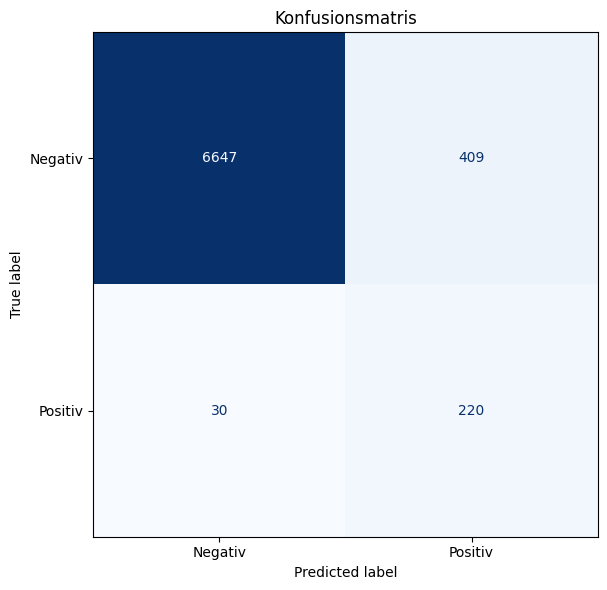

AUC: 0.9698378684807257
Accuracy:  93.99%
FN-rate:   12.00%  (farliga missade fall)
FP-rate:   5.80%  (onödiga larm)
Sensitivitet:   88.00%  (Sannolikhet att upptäcka ett positivt fall)
Specificitet:   94.20%  (Sannolikhet att korrekt klassificera ett negativt fall negativt)
AUC: 0.9698


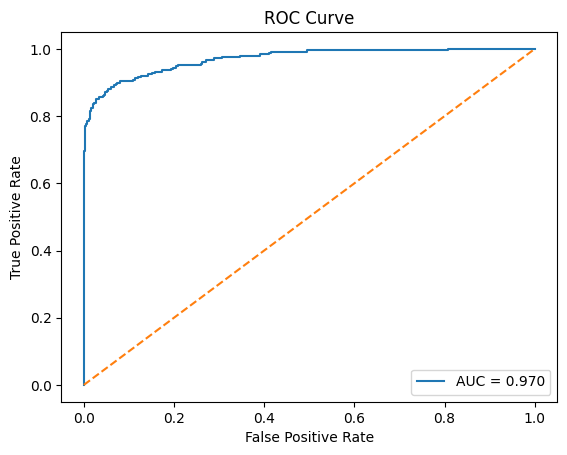

In [3]:
from functions.evaluation import evaluate


test_rows = test_rows[test_rows['label'].isin([0,1])]
result = network.predict(test_rows)
result['cnn_probability'] = result['probability'].copy()
_ = evaluate(result)

<Figure size 640x480 with 0 Axes>

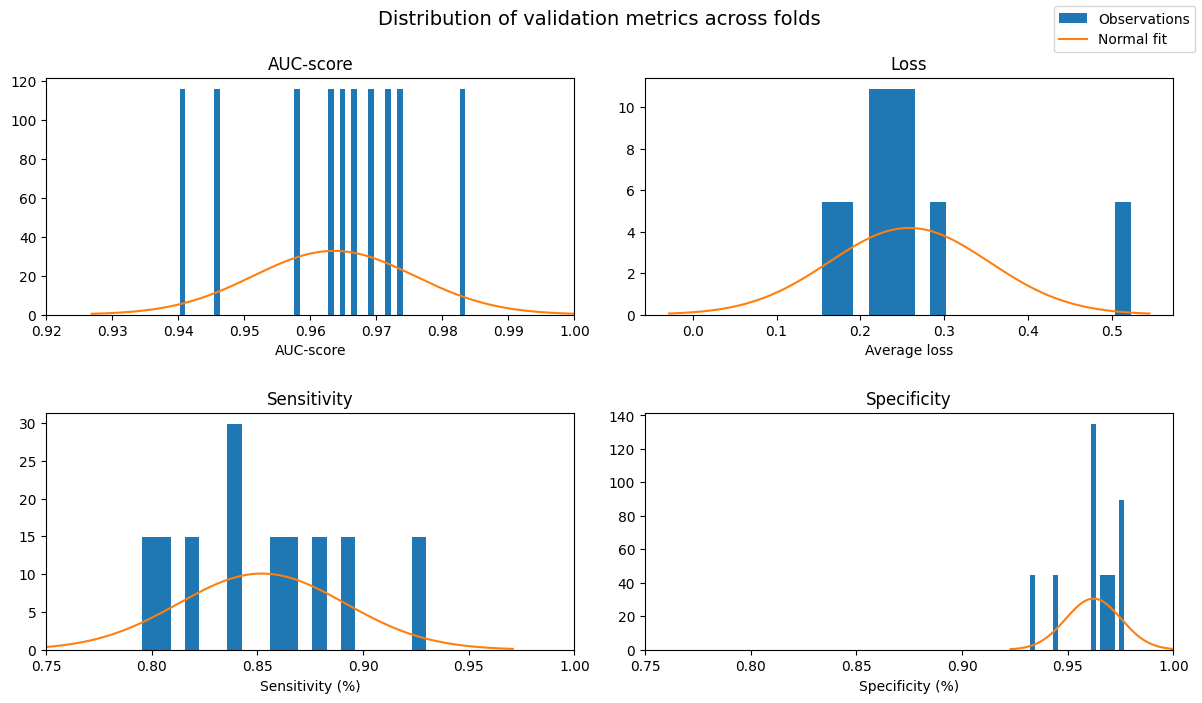

,fold,train_loss,val_loss,val_accuracy,val_auc,val_spec,val_sens,tn,fp,fn,tp
0,1,0.105723,0.245014,95.403900,0.964882,0.970822,0.836431,1830,55,44,225
1,2,0.130051,0.229224,94.661096,0.958151,0.962334,0.836431,1814,71,44,225
2,3,0.223159,0.261767,94.707521,0.940234,0.968700,0.795539,1826,59,55,214
3,4,0.119964,0.218880,96.053853,0.971647,0.975066,0.858736,1838,47,38,231
4,5,0.164329,0.253598,95.682451,0.966744,0.976658,0.817844,1841,44,49,220
5,6,0.209152,0.522979,92.711235,0.962737,0.932095,0.892193,1757,128,29,240
6,7,0.174712,0.290601,94.707521,0.945680,0.967109,0.806691,1823,62,52,217
7,8,0.137428,0.224182,93.546890,0.968815,0.945358,0.866171,1782,103,36,233
8,9,0.165390,0.182607,95.218199,0.973478,0.962314,0.881481,1813,71,32,238
9,10,0.147183,0.154679,95.728877,0.983493,0.961253,0.929630,1811,73,19,251


In [4]:
import pandas as pd
from matplotlib import pyplot as plt
from scipy.stats import norm
import numpy as np
df = pd.read_csv('../models/feed_forward_basic_kfold_metrics.csv')
AUCs = df['val_auc']
loss = df['val_loss']
spec = df['val_spec']
sens = df['val_sens']

plt.figure()
fig, ((ax1, ax2),(ax3,ax4)) = plt.subplots(2, 2, figsize=(12, 7))
fig.suptitle('Distribution of validation metrics across folds', fontsize=14, y=1.02)

plt.tight_layout(rect=[0, 0.05, 1, 1], h_pad=5.0, w_pad=2.0)
ax1.hist(df['val_auc'].sort_values(),bins=50,density=True,label='Observations')
mu = np.mean(AUCs)
std = np.std(AUCs)
x = np.linspace(mu-3*std,mu+3*std,300)
y = norm.pdf(x,mu,std)
ax1.set_xlim(0.92,1.0)
ax1.set_title('AUC-score')
ax1.plot(x,y,label='Normal fit')
ax1.set_xlabel('AUC-score')

ax2.hist(df['val_loss'].sort_values(),bins=20,density=True)
mu = np.mean(loss)
std = np.std(loss)
x = np.linspace(mu-3*std,mu+3*std,300)
y = norm.pdf(x,mu,std)
ax2.set_title('Loss')
ax2.plot(x,y)
ax2.set_xlabel('Average loss')

ax3.hist(df['val_sens'].sort_values(),bins=20,density=True)
mu = np.mean(sens)
std = np.std(sens)
x = np.linspace(mu-3*std,mu+3*std,300)
y = norm.pdf(x,mu,std)
ax3.set_xlim(0.75,1.0)
ax3.set_title('Sensitivity')
ax3.set_xlabel('Sensitivity (%)')
ax3.plot(x,y)

ax4.hist(df['val_spec'].sort_values(),bins=20,density=True)
mu = np.mean(spec)
std = np.std(spec)
x = np.linspace(mu-3*std,mu+3*std,300)
y = norm.pdf(x,mu,std)
ax4.plot(x,y)
ax4.set_title('Specificity')
ax4.set_xlim(0.75,1.0)
ax4.set_xlabel('Specificity (%)')
fig.legend()
plt.show()
df
